In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("raw_datasets/novartis/protacdb2.0_zinc_chembl_dataset.csv")

In [3]:
df

,Unnamed: 0,smiles,Public Source,pred(rLM LogCLint),pred(hLM LogCLint),pred(mLM LogCLint),pred(minipigLM LogCLint),pred(cynoLM LogCLint),pred(dLM LogCLint),pred(LogFu-Rat),...,pred(Direct NIBR LogD7.4),pred(LE-MDCKv2_LogPapp),pred(LE-MDCKv1_LogPapp),pred(Caco-2_LogPapp),pred(MDCK-MDR1_LogER),pred(logPAMPA),pred(logkobs),pred(CYP3A4_pIC50),pred(CYP2C9_pIC50),pred(CYP2D6_pIC50)
0,0,COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN1CCN(C...,PROTAC-DB 2.0,2.091679,2.552630,2.157954,2.259766,2.786120,2.229575,-0.929547,...,2.026738,-0.444264,-0.540984,-0.416682,0.245810,-6.020508,-1.247777,6.198087,4.661767,5.571172
1,1,COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN1CCN(C...,PROTAC-DB 2.0,1.974344,2.348593,2.125387,2.089687,2.510576,1.846213,-0.518404,...,0.401121,-0.537921,-0.526252,-0.289764,0.392459,-5.814249,-2.002865,5.068216,4.647960,4.745326
2,2,COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN1CCN(C...,PROTAC-DB 2.0,2.022209,2.420409,2.156182,2.211257,2.588093,2.048729,-0.583118,...,0.294822,-0.509577,-0.495706,-0.442113,0.330820,-5.934164,-1.895290,5.349257,4.653561,4.733343
3,3,COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN1CCN(C...,PROTAC-DB 2.0,2.451464,2.651443,2.572476,2.435035,2.871812,2.189433,-1.481396,...,2.362014,-0.247690,-0.407338,-0.170919,0.570917,-5.774035,-1.471675,6.076886,4.917759,5.409411
4,4,COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN1CCN(C...,PROTAC-DB 2.0,2.428077,2.671555,2.536674,2.504483,2.857908,2.324770,-1.421176,...,2.028686,-0.330597,-0.417062,-0.357741,0.439427,-5.900461,-1.373242,6.198383,4.883762,5.289637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273701,273701,CCOc1ccc([C@H]2CCCN2C(=O)CSc2ncnc3c2cnn3C)cc1,ZINC,2.860544,2.575638,2.733099,2.508182,2.859033,2.457135,-0.918440,...,2.697228,1.412542,1.239641,1.543414,0.031427,-3.529549,-1.744253,5.151199,4.661434,4.644837
273702,273702,Cc1ccc(C)c(C(=O)[C@H](C)Sc2nc3ccccc3c(=O)n2CCC...,ZINC,2.823697,2.546919,2.856322,2.519230,2.813423,2.307438,-1.782176,...,2.876859,1.382718,0.819353,1.222213,-0.018147,-4.018200,-1.846530,4.737861,4.745138,4.543331
273703,273703,Cc1cccc(OC[C@@H](C)NC(=O)c2c(C)c3ccccc3oc2=O)c1,ZINC,2.807635,2.629704,2.804585,2.527475,2.839678,2.676757,-1.887363,...,3.448678,1.510726,0.770743,0.650226,-0.190577,-4.283741,-2.214984,4.589895,4.659507,4.600844
273704,273704,COCCCOc1cccc(CN[C@@H](C)c2ccc3[nH]c(=O)[nH]c3c...,ZINC,2.267159,1.980153,2.134088,2.315734,2.453495,2.047525,-1.265178,...,2.885536,0.741505,0.747712,0.509092,0.999448,-5.024880,-1.969058,4.615831,4.660003,4.828861


In [4]:
df_remove = df[["smiles", "Public Source", "pred(hLM LogCLint)"]].dropna().reset_index(drop=True)

In [5]:
df_remove

,smiles,Public Source,pred(hLM LogCLint)
0,COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN1CCN(C...,PROTAC-DB 2.0,2.552630
1,COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN1CCN(C...,PROTAC-DB 2.0,2.348593
2,COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN1CCN(C...,PROTAC-DB 2.0,2.420409
3,COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN1CCN(C...,PROTAC-DB 2.0,2.651443
4,COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN1CCN(C...,PROTAC-DB 2.0,2.671555
...,...,...,...
273633,CCOc1ccc([C@H]2CCCN2C(=O)CSc2ncnc3c2cnn3C)cc1,ZINC,2.575638
273634,Cc1ccc(C)c(C(=O)[C@H](C)Sc2nc3ccccc3c(=O)n2CCC...,ZINC,2.546919
273635,Cc1cccc(OC[C@@H](C)NC(=O)c2c(C)c3ccccc3oc2=O)c1,ZINC,2.629704
273636,COCCCOc1cccc(CN[C@@H](C)c2ccc3[nH]c(=O)[nH]c3c...,ZINC,1.980153


In [6]:
df_remove["hlm_value_unscaled"] = 10 ** df_remove["pred(hLM LogCLint)"]
df_remove["hlm_value_unscaled_log1p"] = np.log1p(df_remove["hlm_value_unscaled"])

df_remove["hlm_value_scaled"] = 10 ** df_remove["pred(hLM LogCLint)"]
df_remove["hlm_value_scaled_log1p"] = np.log1p(df_remove["hlm_value_scaled"])

In [7]:
df_remove

,smiles,Public Source,pred(hLM LogCLint),hlm_value_unscaled,hlm_value_unscaled_log1p,hlm_value_scaled,hlm_value_scaled_log1p
0,COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN1CCN(C...,PROTAC-DB 2.0,2.552630,356.968685,5.880446,356.968685,5.880446
1,COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN1CCN(C...,PROTAC-DB 2.0,2.348593,223.148143,5.412307,223.148143,5.412307
2,COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN1CCN(C...,PROTAC-DB 2.0,2.420409,263.274371,5.576988,263.274371,5.576988
3,COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN1CCN(C...,PROTAC-DB 2.0,2.651443,448.170567,6.107403,448.170567,6.107403
4,COc1cc(-c2cn(C)c(=O)c3cnccc23)cc(OC)c1CN1CCN(C...,PROTAC-DB 2.0,2.671555,469.412981,6.153611,469.412981,6.153611
...,...,...,...,...,...,...,...
273633,CCOc1ccc([C@H]2CCCN2C(=O)CSc2ncnc3c2cnn3C)cc1,ZINC,2.575638,376.389910,5.933279,376.389910,5.933279
273634,Cc1ccc(C)c(C(=O)[C@H](C)Sc2nc3ccccc3c(=O)n2CCC...,ZINC,2.546919,352.305450,5.867333,352.305450,5.867333
273635,Cc1cccc(OC[C@@H](C)NC(=O)c2c(C)c3ccccc3oc2=O)c1,ZINC,2.629704,426.288896,6.057460,426.288896,6.057460
273636,COCCCOc1cccc(CN[C@@H](C)c2ccc3[nH]c(=O)[nH]c3c...,ZINC,1.980153,95.532924,4.569884,95.532924,4.569884


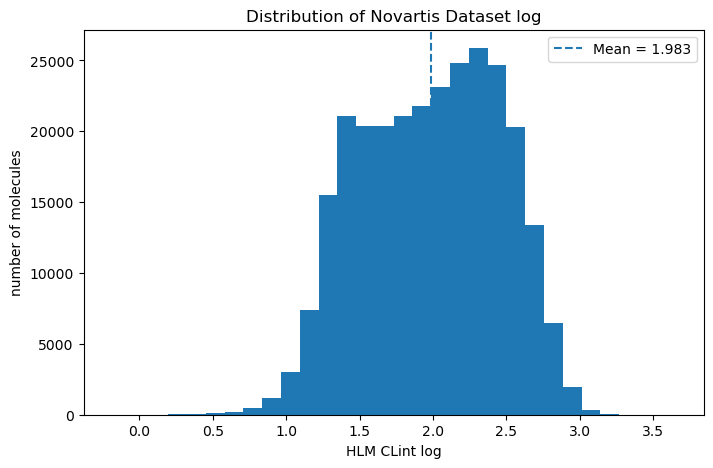

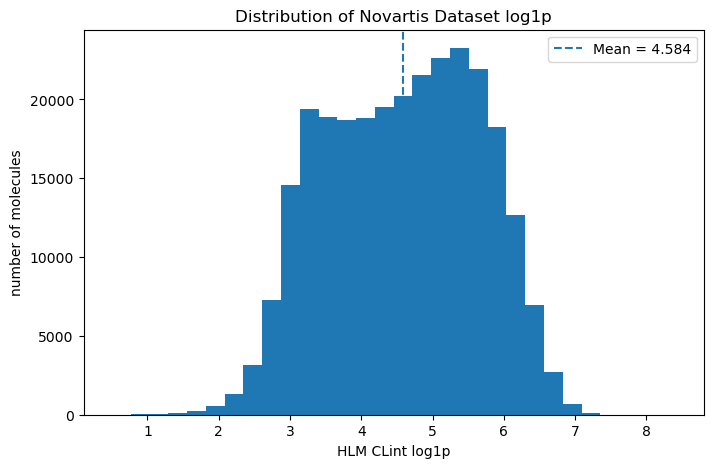

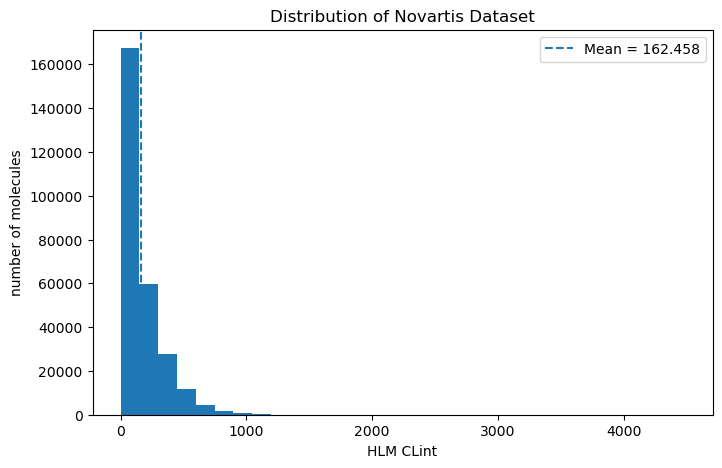

In [11]:
import matplotlib.pyplot as plt

# Mean values
mean_log = df_remove["pred(hLM LogCLint)"].mean()
mean_log1p = df_remove["hlm_value_scaled_log1p"].mean()
mean_value = df_remove["hlm_value_scaled"].mean()

plt.figure(figsize=(8, 5))
plt.hist(df_remove["pred(hLM LogCLint)"], bins=30)
plt.axvline(mean_log, linestyle="--", label=f"Mean = {mean_log:.3f}")
plt.xlabel("HLM CLint log")
plt.ylabel("number of molecules")
plt.title("Distribution of Novartis Dataset log")
plt.legend()
plt.show()

# Plot 1: distribution of hlm_value_log10
plt.figure(figsize=(8, 5))
plt.hist(df_remove["hlm_value_scaled_log1p"], bins=30)
plt.axvline(mean_log1p, linestyle="--", label=f"Mean = {mean_log1p:.3f}")
plt.xlabel("HLM CLint log1p")
plt.ylabel("number of molecules")
plt.title("Distribution of Novartis Dataset log1p")
plt.legend()
plt.show()

# Plot 2: distribution of hlm_value
plt.figure(figsize=(8, 5))
plt.hist(df_remove["hlm_value_scaled"], bins=30)
plt.axvline(mean_value, linestyle="--", label=f"Mean = {mean_value:.3f}")
plt.xlabel("HLM CLint")
plt.ylabel("number of molecules")
plt.title("Distribution of Novartis Dataset")
plt.legend()
plt.show()

In [9]:
df_remove["dataset"] = "novartis_dataset"
df_remove["data_year"] = "2024"
df_remove.to_csv("adjusted_datasets/novartis_dataset_adjusted.csv")